# ARIN 5101 - Programming Assignment 2

**Objective:** This assignment focuses on improving an existing Logistic Regression class built on the one discussed in the lectures. You will improve the class in the following aspects:

- GD, Mini-batch, and SGD
- Loss calculation and reporting
- Early stopping

You will also test your model in some real world data. Please complete all your work in this Jupyter notebook.

**Instructions**:  
1. Save this file as a Jupyter notebook named `arin5101_pa2_YourName.ipynb`.  
2. Add comments to explain your code, which helps with clarity.  
3. Use your own Anaconda installation or Virtual Barn to access the Jupyter notebook. More details for Virtual Barn available here: https://itso.hkust.edu.hk/services/academic-teaching-support/facilities/virtual-barn  
4. Ensure all code runs without errors in a standard Python environment with Scikit-learn, NumPy, Pandas, and Matplotlib installed. **Grading of this work will be based on the Anaconda installation in the Virtual Barn**.
5. Avoid copying solutions from external sources (e.g., GitHub, AI tools), focus on your own reasoning and implementation.  
6. We have already implemented Perceptron and Logistic Regression classes at the beginning. Please reuse methods/functions across questions where possible for efficiency. Make sure you do not change the given classes so that your answers work consistently.
7. Submit the completed notebook via **https://canvas.ust.hk/courses/64868/assignments/404855** by **Sunday November 9 11:59PM**.  

**Total Points**: 100 (6 questions)

## Setup - Imports and Utilities

**Instruction:**

- Run this code before you work on the questions.
- _Do not modify this code._

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.multiclass import unique_labels
from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.model_selection import GridSearchCV
import pandas as pd
import time

## Perceptron (Review)
**Instructions:**

- Review and run the provided **Perceptron** implementation.
- _Do not modify this code._

In [ ]:
##### Don't change this class #####

"""
This is a basic Perceptron class built for binary classification
"""
# BaseEstimator and ClassifierMixin are required for Scikit-learn
class Perceptron(ClassifierMixin, BaseEstimator):
    # lr is the learning rate
    # n_iter is the number of iterations to run the training
    def __init__(self, lr=0.01, n_iter=100):
        self._lr = lr
        self._n_iter = n_iter

    # This method computes the score of the model
    def _decision_function(self, X, w, b):
        return np.dot(X, w) + b

    # This method is the step function for this Perceptron
    def _activation_function(self, y):
        return np.where(y < 0, 0, 1)

    # This method trains the model based on the input X and label y
    def fit(self, X, y):
        # Initialize weights and bias
        self._w = np.zeros(X.shape[1])
        self._b = 0.

        # Train for the maximum iterations
        for epoch in range(1, self._n_iter + 1):
            for x, y_true in zip(X, y):
                # Compute the prediction of the sample
                raw_output = self._decision_function(x, self._w, self._b)
                y_hat = self._activation_function(raw_output)

                # Compute the update
                update = self._lr * (y_true - y_hat)
                self._w += update * x
                self._b += update

        return self._w, self._b

    # This method predicts the label of some test data X
    def predict(self, X):
        raw_output = self._decision_function(X, self._w, self._b)
        return self._activation_function(raw_output)

    # This method is needed for GridSearchCV
    def get_params(self, deep=True):
        return { "lr": self._lr, "n_iter": self._n_iter }
    
    # This method is needed for GridSearchCV
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, f"_{key}", value)
        return self

## Logistic Regression (Review)
**Instructions:**

- Review and run the provided **LogisticRegression** implementation that extends **Perceptron**.
- _Do not modify this code._

In [ ]:
##### Don't change this class #####

"""
This is a LogisticRegression class built from the notes
"""
class LogisticRegression(Perceptron):
    def __init__(self, penalty=None, r_lambda=0.0, **kwargs):
        super().__init__(**kwargs)
        self._penalty = penalty
        self._lambda = r_lambda

    # This function implements a sigmoid activation
    def _activation_function(self, y):
        return 1.0 / (1.0 + np.exp(-y))

    # This method extends the prediction with a threshold function
    def predict(self, X):
        raw_output = self._decision_function(X, self._w, self._b)
        p = self._activation_function(raw_output)
        return np.where(p >= 0.5, 1, 0)    

    # This method returns the prediction probabilities for both classes
    def predict_proba(self, X):
        raw_output = self._decision_function(X, self._w, self._b)
        p = self._activation_function(raw_output)
        p = p[:, np.newaxis]
        return np.hstack((1 - p, p))

    # This method computes the loss function
    def _loss_function(self, y, p):
        # Clip to avoid log(0)
        eps = 1e-15
        p = np.clip(p, eps, 1 - eps)

        # Regularization
        match self._penalty:
            case "l1":
                penalty = self._lambda * np.sum(np.abs(self._w))
            case "l2":
                penalty = self._lambda * np.sum(self._w ** 2)
            case _:
                penalty = 0

        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)) + penalty

    # This method initializes the weights and bias
    def _initialize_weights(self, dim):
        # Initialize weights and bias
        self._w = np.zeros(dim)
        self._b = 0.

    # This method trains the model by updating the weights and bias
    def _train(self, X, y):
        # Aggregate the loss values
        self.loss_ = []

        for epoch in range(1, self._n_iter + 1):
            # Compute the prediction of all samples
            raw_output = self._decision_function(X, self._w, self._b)
            p = self._activation_function(raw_output)

            # Compute the update
            self._update_weights(X, y, p)

            # Compute the loss
            self.loss_.append(self._loss_function(y, p))

        # Report the actual number of iterations
        self.n_iter_ = self._n_iter
    
    # This method updates the weights and bias
    def _update_weights(self, X, y, p):
        error = p - y

        # Regularization
        match self._penalty:
            case "l1":
                penalty = self._lambda * np.sign(self._w)
            case "l2":
                penalty = self._lambda * 2 * self._w
            case _:
                penalty = 0
                
        self._w -= self._lr * (np.dot(X.T, error) / X.shape[0] + penalty)
        self._b -= self._lr * np.mean(error)

    # This method updates the class attributes
    def _update_attributes(self):
        # Make the weights and bias available
        # Added underscore for Scikit-learn format
        self.coef_ = self._w
        self.intercept_ = self._b
    
    # This method trains the model using gradient descent
    def fit(self, X, y):
        # Property for Scikit-learn GridSearchCV
        self.classes_ = unique_labels(y)

        # Initialize weights and bias
        self._initialize_weights(X.shape[1])

        # Train for the maximum iterations
        self._train(X, y)

        # Make some parameters available
        self._update_attributes()

        return self

    # This method is needed for Scikit-learn GridSearchCV
    def get_params(self, deep=True):
        params = super().get_params(deep)
        params["penalty"] = self._penalty
        params["r_lambda"] = self._lambda
        return params
    
    # This method is needed for Scikit-learn GridSearchCV
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, f"_{key}", value)
        return self

## Working on the LogisticRegressionSGD Class

**Task:** A working **LogisticRegressionSGD** class is given below. You will improve the class in several aspects. You are recommended to do them one by one so that you finish one improvement before working on another.

**Class Parameters:** In addition to the existing parameters from **LogisticRegression**, the class has the following new parameters:

- **solver: _{'gd', 'mini-batch', 'sgd'}, default='gd'_**

  The solver to be used. 'gd' uses full-batch gradient descent, 'mini-batch' uses mini-batch gradient descent, while 'sgd' uses stochastic gradient descent.
  
- **batch_size: _int, default=32_**

  The batch size to be used when the solver is 'mini-batch'.

- **verbose: _{True, False}, default=False_**

  The training loop will report the epoch number and its loss value when verbose is True.

- **tol: _float or None, default=None_**

  The tolerance to be used for early stopping. If the tolerance is None, early stopping is disabled. If the tolerance is a number, the training loop will stop early when the loss does not improve by the tolerance in two consecutive epochs, i.e. loss[-2] - loss[-1] < tol.

**Instructions:**

**<u>For Question 1 to Question 3</u>**

- Work on the questions and test your result **one by one**.
- Add your code for Question 1 to Question 3 to **the same class** shown below.

In [ ]:
"""
This is a LogisticRegressionSGD class based on LogisticRegression
"""
class LogisticRegressionSGD(LogisticRegression):
    def __init__(self, *args, solver="gd", batch_size=32, verbose=False, tol=None, **kwargs):
        super().__init__(*args, **kwargs)

        # For Question 1
        self._solver = solver # can be either "gd", "mini-batch" or "sgd"
        self._batch_size = batch_size

        # For Question 2
        self._verbose = verbose # can be either True or False

        # For Question 3
        self._tol = tol # can be None

    # This method trains the model by updating the weights and bias
    def _train(self, X, y):
        #
        # You need to work on this function
        #

        # For Question 1
        # 1. Copy the code from LogisticRegression and change from there
        # 2. Change the training loop so that:
        #    i. Shuffle the dataset in each epoch
        #    ii. Make an additional loop for batched data (batch size depends on the solver
        #    iii. Calculate the loss value at the end of each epoch

        # For Question 2
        # - Print the current epoch number and loss value when verbose is True

        # For Question 3
        # - Stop the training loop when the loss value of two consecutive epoch is not improved by more than tol
        # Question 1
        # Aggregate the loss values
        self.loss_ = []

        # Random number generator
        rng = np.random.default_rng()

        # Determine the batch size for different solvers
        n_samples = X.shape[0]
        if self._solver == "gd":
            # Full batch
            d_batch_size = n_samples
        elif self._solver == "mini-batch":
            # Original batch
            d_batch_size = self._batch_size
        elif self._solver == "sgd":
            # Single sample
            d_batch_size = 1
        else:
            raise ValueError(f"Invalid solver: {self._solver}. Choose 'gd', 'mini-batch', or 'sgd'.")   

        # Report the actual number of iterations
        # For Q3, move this here
        self.n_iter_ = self._n_iter

        for epoch in range(1, self._n_iter + 1):
            # Shuffle dataset at first
            shuffled_idx = rng.permutation(n_samples)
            X_shuffled = X[shuffled_idx]
            y_shuffled = y[shuffled_idx]

            # Number of batches
            n_batches = int(np.ceil(n_samples / d_batch_size))
            # Loop for batches
            for batch_idx in range(n_batches):
                start = batch_idx * d_batch_size
                end = start + d_batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                
                # Compute the prediction of all samples
                raw_output_batch = self._decision_function(X_batch, self._w, self._b)
                p_batch = self._activation_function(raw_output_batch)

                # Compute the update each batch
                self._update_weights(X_batch, y_batch, p_batch)

            # Compute the loss each epoch
            raw_output_epoch = self._decision_function(X, self._w, self._b)
            p_epoch = self._activation_function(raw_output_epoch)
            epoch_loss = self._loss_function(y, p_epoch)
            self.loss_.append(epoch_loss)

            # Question 2：Print when 'verbose'
            if self._verbose:
                print(f"Epoch {epoch}: Loss =  {epoch_loss:.4f}")

            #Question 3 : Early stopping
            if self._tol is not None and len(self.loss_) >= 2:
                # Compute the loss improvement between 2 epochs
                loss_improvement = self.loss_[-2] - self.loss_[-1]
                # Early stopping logic
                if loss_improvement < self._tol:
                    self.n_iter_ = epoch
                    if self._verbose:
                        print(f"Early stopping at epoch {epoch}.")
                    break
    
    def get_params(self, deep=True):
        params = super().get_params(deep)
        params["solver"] = self._solver
        params["batch_size"] = self._batch_size
        params["tol"] = self._tol
        return params

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, f"_{key}", value)
        return super().set_params(**params)

## Question 1 - Implement **LogisticRegressionSGD._train(self, X, y)**
**Task:** Implement the **_train(self, X, y)** method that supports three solvers: 'gd', 'mini-batch' and 'sgd'.

**Instructions:**

- Copy the code of **_train(self, X, y)** from **LogisticRegression** to **LogisticRegressionSGD**.
- Shuffle the dataset at the start of each epoch.
- Determine the batch size for the solver when it is 'gd', 'mini-batch' or 'sgd', before the training loop.
- Add a new loop inside each epoch to go through the batches of data instead of the full batch as in **LogisticRegression**.
- Compute the loss value for the _entire dataset_ at the end of each epoch (not for each batch).
- _Write your code in the **LogisticRegressionSGD** class above_


**Expected Output:**

Correct output generated by the sanity test.

**Hint:**

- Follow the same gradient calculation, and weights and bias update in **LogisticRegression._train(self, X, y)**, but loop over batches according to the solver.
- Use **np.random.default_rng()** to get a random generator and use its **permutation()** method to shuffle the dataset at the start of each epoch.
- The new loop structure should look like this:
  ```python
  # Determine the batch size
  ...
  
  for epoch in ...: # for each epoch
      # Shuffle dataset
      ...
  
      for batch_index in ...: # for each batch
          # Obtain the batch data
          ...
      
          # Update weights and bias for the batch
          ...

      # Loss calculation for the full dataset
      ...
      self.loss_.append(...)
  ```

### Sanity Test (tiny dataset)

**Task:** Verify **_train(self, X, y)** correctness on a 4×2 toy dataset.

**Instructions:**

- Run a single **fit** for each solver and print learned weights, bias, and final loss.
- **Note**: Due to the shuffling, the values may differ slightly, but the numbers should be close.
-  _Do not modify this code._

**Expected Output:** 

```
       Solver           Weights    Bias  Final Loss
0          gd  [0.2045, 0.2045] -0.7959    0.539659
1  mini-batch  [0.5134, 0.5145] -1.2474    0.461462
2         sgd  [1.0478, 1.0443] -1.9418    0.359907
```

In [ ]:
# Tiny linearly-separable dataset (AND-like)
X_tiny = np.array([[0., 0.],
                   [0., 1.],
                   [1., 0.],
                   [1., 1.]])
y_tiny = np.array([0, 0, 0, 1])

# Create a list to store results
results = []

# Single pass training for gd model
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=50, solver="gd")
tiny_model.fit(X_tiny, y_tiny)
results.append(["gd", np.round(tiny_model.coef_, 4), np.round(tiny_model.intercept_, 4), np.round(tiny_model.loss_[-1], 6)])

# Single pass training for mini-batch model
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=50, batch_size=2, solver="mini-batch")
tiny_model.fit(X_tiny, y_tiny)
results.append(["mini-batch", np.round(tiny_model.coef_, 4), np.round(tiny_model.intercept_, 4), np.round(tiny_model.loss_[-1], 6)])

# Single pass training for sgd model
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=50, solver="sgd")
tiny_model.fit(X_tiny, y_tiny)
results.append(["sgd", np.round(tiny_model.coef_, 4), np.round(tiny_model.intercept_, 4), np.round(tiny_model.loss_[-1], 6)])

# Create a DataFrame to display results in a table
results_df = pd.DataFrame(results, columns=["Solver", "Weights", "Bias", "Final Loss"])

# Print the results table
print(results_df)

## Question 2 - Loss Reporting

**Task:** Print the epoch number and loss during training if **verbose** is True.

**Instructions:**

- Only generate the report when **verbose** is True.
- Add a **print()** at the end of the training loop to report the epoch number and loss during each epoch in the training loop.
- _Write your code in the **LogisticRegressionSGD** class above_
 
**Expected Output:**

Correct reporting of epoch number and loss value during training in the sanity test.

### Sanity Test (tiny dataset)

**Task:** Verify the epoch number and loss are reported correctly on a 4×2 toy dataset.

**Instructions:**

- Run a single **fit** and examine the training reporting.
-  _Do not modify this code._

**Expected Output:** 

```
Epoch 1: Loss = 0.6870
Epoch 2: Loss = 0.6811
Epoch 3: Loss = 0.6755
Epoch 4: Loss = 0.6702
Epoch 5: Loss = 0.6651
Epoch 6: Loss = 0.6602
Epoch 7: Loss = 0.6555
Epoch 8: Loss = 0.6511
Epoch 9: Loss = 0.6468
Epoch 10: Loss = 0.6426
```

In [ ]:
# Tiny linearly-separable dataset (AND-like)
X_tiny = np.array([[0., 0.],
                   [0., 1.],
                   [1., 0.],
                   [1., 1.]])
y_tiny = np.array([0, 0, 0, 1])

# Single pass training for gd model
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=10, solver="gd", verbose=True)
tiny_model.fit(X_tiny, y_tiny);

## Question 3 - Early Stopping

**Task:** Use the **tol** parameter to stop the training loop early.

**Instructions:**

- Apply early stopping when **tol** is a number.
- Compute the loss improvement between the last two loss values at the end of the training loop.
- Stop the training loop when the improvement is smaller than **tol**.
- Display the stopping epoch number when **verbose** is True.
- Make sure **self.n_iter_** contains the actual number of iterations used.
- _Write your code in the **LogisticRegressionSGD** class above_
 
**Expected Output:**

The training loop is stopped at the correct epoch number during training in the sanity test.

### Sanity Test (tiny dataset)

**Task:** Verify the early stopping on a 4×2 toy dataset. 

**Instructions:**

- Run **fit** with a tolerance of 0.01, without verbose.
- Run **fit** with a tolerance of 0.05, with verbose.
- Run **fit** with a tolerance of 0.001, with verbose.
-  _Do not modify this code._

**Expected Output:** 

```
GD training with tol=0.01:
Loss = 0.6811
Number of Iterations = 2

GD training with tol=0.005 (verbose):
Epoch 1: Loss = 0.6870
Epoch 2: Loss = 0.6811
Epoch 3: Loss = 0.6755
Epoch 4: Loss = 0.6702
Epoch 5: Loss = 0.6651
Epoch 6: Loss = 0.6602
Early stopping at epoch 6.

GD training with tol=0.001 (verbose):
Epoch 1: Loss = 0.6870
Epoch 2: Loss = 0.6811
Epoch 3: Loss = 0.6755
Epoch 4: Loss = 0.6702
Epoch 5: Loss = 0.6651
Epoch 6: Loss = 0.6602
Epoch 7: Loss = 0.6555
Epoch 8: Loss = 0.6511
Epoch 9: Loss = 0.6468
Epoch 10: Loss = 0.6426
Number of iterations = 10
```

In [ ]:
# Tiny linearly-separable dataset (AND-like)
X_tiny = np.array([[0., 0.],
                   [0., 1.],
                   [1., 0.],
                   [1., 1.]])
y_tiny = np.array([0, 0, 0, 1])

# Using tol=0.01 and verbose=False
print("GD training with tol=0.01:")
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=10, solver="gd", tol=0.01)
tiny_model.fit(X_tiny, y_tiny)
print(f"Loss = {tiny_model.loss_[-1]:.4f}")
print(f"Number of iterations = {tiny_model.n_iter_}")

print()

# Using tol=0.005 and verbose=True
print("GD training with tol=0.005 (verbose):")
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=10, solver="gd", tol=0.005, verbose=True)
tiny_model.fit(X_tiny, y_tiny)

print()

# Using tol=0.001 and verbose=True
print("GD training with tol=0.001 (verbose):")
tiny_model = LogisticRegressionSGD(lr=0.1, n_iter=10, solver="gd", tol=0.001, verbose=True)
tiny_model.fit(X_tiny, y_tiny)
print(f"Number of iterations = {tiny_model.n_iter_}")

## Question 4 — Data Preparation (Real Dataset)

**Task:**  Load and prepare a real dataset for testing.

**Instructions:**

- Load the **Breast Cancer Wisconsin** dataset (**sklearn.datasets.load_breast_cancer**)
- Split into train/test using a ratio of 80/20
- **Standardize** features using **StandardScaler**.
- Display the shapes of **(X_train, X_test, y_train, y_test)** the information of the training dataset (use **df.describe()** on **X_train**) to confirm that scaling succeeded.
- **Data Source**: If you want to learn more about this data set, you can read the details from here:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**Expected Output:**

```
(455, 30) (114, 30) (455,) (114,)
```
and a dataframe with 8 rows by 30 columns, with count = 455, mean ~ 0 and std ~ 1 for each column

In [ ]:
from sklearn.datasets import load_breast_cancer

#
# Write your code here
#
# Question 4： Real Dataset
# Load required
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split into 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size= 0.2,  # ratio
    random_state= 50
)

# Standardize features using StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pd.set_option('display.float_format', '{:.6f}'.format)
# Display
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# DataFrame converted
train_df = pd.DataFrame(X_train, columns=cancer.feature_names)
train_df.describe()

## Question 5 - Compare Solvers

**Task:** Compare the loss for the three solvers.

**Instructions:**

- Train the **LogisticRegressionSGD** model using  the Breast Cancer Wisconsin dataset.
- Use this parameters:
  - Iteration numbers = 100.
  - Solvers = 'gd', 'mini-batch' or 'sgd'.
  - Default values for other parameters.
- Plot loss vs. epoch for each solver in the same plot and observe the convergence time.

**Expected Output:**

A plot showing the trend of loss for the three solvers over 100 iterations during training.
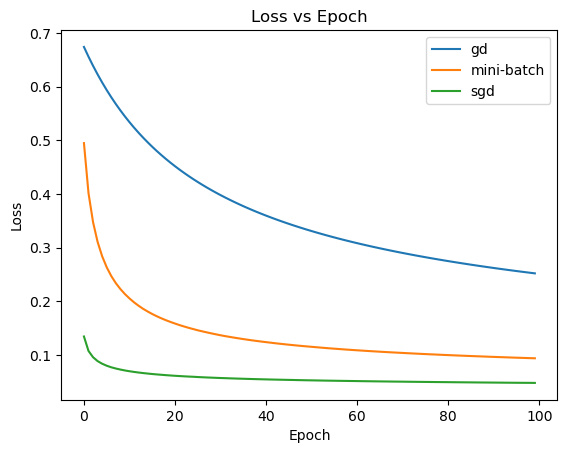

In [ ]:

#
# Write your code here
#
# Question 5 : Compare solvers
# Training for three solvers
solvers = ["gd", "mini-batch", "sgd"]
loss_compare = {}

for solver in solvers:
    # Model and Parameters
    model = LogisticRegressionSGD(
        lr=0.01,  
        n_iter=100,
        solver=solver,
        batch_size=32,
        verbose=False
    )

    # Training and Comparing
    model.fit(X_train, y_train)
    loss_compare[solver] = model.loss_

# Plot loss vs. epoch
plt.figure(figsize=(10, 6))
for solver in solvers:
    epochs = range(1, len(loss_compare[solver]) + 1)
    plt.plot(epochs, loss_compare[solver], label=f'{solver}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()


## Question 6 - Best Parameters

**Task:** Identify the best parameters based on **GridSearchCV** results.

**Instructions:**

- Use **GridSearchCV** to compare different parameters for:
  - The three solvers ('gd', 'mini-batch', 'sgd').
  - The iteration values of 10, 50, 100.
  - The tolerance values of 0.01, 0.001, 0.0001.
  - Default values for other parameters.
- Use 'accuracy' scoring.
- Put **cv_results_** in a DataFrame.
- Keep only the columns 'mean_test_score', 'mean_fit_time', 'param_n_iter', 'param_solver', 'param_tol' and sort the DataFrame with mean_test_score in descending order and mean_fit_time in ascending order.
- Print the DataFrame and observe which parameters give you the best result (score vs time).

**Expected Output:**

A DataFrame that:
- contains the columns 'mean_test_score', 'mean_fit_time', 'param_n_iter', 'param_solver' and 'param_tol'.
- has the rows sorted by mean_test_score in descending order and mean_fit_time in ascending order.

Here is an example output.

```
    mean_test_score  mean_fit_time  param_n_iter param_solver  param_tol
7          0.978022       0.199640            10          sgd     0.0010
16         0.978022       0.365244            50          sgd     0.0010
24         0.975824       0.078606           100          sgd     0.0100
6          0.975824       0.078869            10          sgd     0.0100
15         0.975824       0.079990            50          sgd     0.0100
23         0.975824       0.084640           100   mini-batch     0.0001
8          0.975824       0.200593            10          sgd     0.0001
17         0.975824       1.003293            50          sgd     0.0001
25         0.973626       0.331428           100          sgd     0.0010
26         0.973626       1.636363           100          sgd     0.0001
22         0.967033       0.039481           100   mini-batch     0.0010
14         0.967033       0.043697            50   mini-batch     0.0001
13         0.967033       0.046484            50   mini-batch     0.0010
21         0.953846       0.006230           100   mini-batch     0.0100
3          0.953846       0.008586            10   mini-batch     0.0100
5          0.953846       0.010107            10   mini-batch     0.0001
4          0.953846       0.010517            10   mini-batch     0.0010
12         0.953846       0.015697            50   mini-batch     0.0100
19         0.953846       0.023026           100           gd     0.0010
20         0.953846       0.025003           100           gd     0.0001
11         0.938462       0.012248            50           gd     0.0001
10         0.938462       0.012863            50           gd     0.0010
2          0.925275       0.000999            10           gd     0.0001
9          0.925275       0.001158            50           gd     0.0100
1          0.925275       0.002646            10           gd     0.0010
0          0.925275       0.003092            10           gd     0.0100
18         0.925275       0.006577           100           gd     0.0100
```

**Hints:**

- You can use **df.sort_values()** to help you sort the DataFrame

In [ ]:

#
# Write your code here
#
# Question 6 : Best Parameters
# Parameters to be compared
param_grid = {
    'solver': ['gd', 'mini-batch', 'sgd'],  # Solvers
    'n_iter': [10, 50, 100],                # Iter
    'tol': [0.01, 0.001, 0.0001]            # Early stopping param
}

model = LogisticRegressionSGD(lr=0.01, verbose=False)

# Use GridSearchCV with 'accuracy'
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy', 
    cv=5,                       
)

grid_search.fit(X_train, y_train)

# Convert DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Keep colums
selected_columns = [
    'mean_test_score', 
    'mean_fit_time',  
    'param_n_iter',   
    'param_solver',    
    'param_tol'           
]
cv_results = cv_results[selected_columns]

# Required order
cv_results = cv_results.sort_values(
    by=['mean_test_score', 'mean_fit_time'],
    ascending=[False, True]
)

# Display results
results = pd.DataFrame(cv_results)
results